# Day 13: Klasik Segmentasyon Kıyaslaması (Otsu, Watershed, GrabCut)

**Aşama:** Faz 2: Endüstriyel Görüntü İşleme (Day 13)  
**Konu:** Otsu Global & Multi-Otsu, İşaretçi Kontrollü Watershed (Havza), GrabCut GMM Enerji Minimizasyonu ve Halı Jakar Deseni Ayrıştırma Kıyaslama Laboratuvarı  
**Yazar:** Seydi Eryılmaz (@seydivakkas)  
**Telif Hakkı:** (c) 2026 Seydi Eryılmaz. Özel Lisans — Tüm Hakları Saklıdır.

---

## 1. Problem ve Endüstriyel Motivasyon
Merinos halı dokuma tezgâhlarında üretilen jakarlı, bordürlü ve madalyonlu halılarda zemin ile motif desenlerinin yüksek doğruluk ve gerçek zamanlı hızla birbirinden ayrıştırılması (segmentasyon) zorunludur.
Ayrıştırılan motif alanları; ilmek yoğunluğu sayımı, renk sapma analizi ve iplik kopma kusurlarının lokalizasyonunda temel maske katmanı olarak kullanılır.
Bu çalışmada üç klasik bilgisayarlı görü segmentasyon ailesi kafa kafaya kıyaslanmaktadır:
1. **Otsu Global ve Çok Seviyeli Eşikleme** (Ultra-hızlı, histogram bazlı)
2. **İşaretçi Kontrollü Watershed** (Topografik su baskını ve Öklid mesafe dönüşümü bazlı)
3. **GrabCut** (Gauss Karışım Modeli - GMM ve Min-Cut/Max-Flow enerji optimizasyonu bazlı)


## 2. Otsu Matematiksel Teorisi (Sınıflar Arası Varyans Maksimizasyonu & Multi-Otsu)

Nobuyuki Otsu (1979) tarafından geliştirilen yöntem, piksel yoğunluk histogramını iki sınıfa ($C_0$: arka plan, $C_1$: ön plan) bölen ve sınıflar arası varyansı (between-class variance) maksimize eden optimal eşik $t^*$ değerini analitik olarak bulur:

$$\sigma_B^2(t) = \omega_0(t) \, \omega_1(t) \, [\mu_0(t) - \mu_1(t)]^2$$

Burada:
- $\omega_0(t) = \sum_{i=0}^t p_i$ ($C_0$ sınıfının oluşma olasılığı)
- $\omega_1(t) = \sum_{i=t+1}^{L-1} p_i$ ($C_1$ sınıfının oluşma olasılığı)
- $\mu_0(t), \mu_1(t)$: Sınıfların ortalama gri ton değerleri.

Çok Seviyeli Otsu (Multi-Otsu) ise $K-1$ adet eşik seçerek $K$ adet sınıfı birbirinden ayırır ve halıdaki zemin, bordür ve iç motif tonlarını kademelendirir.


## 3. Marker-Controlled Watershed (Öklid Mesafe Dönüşümü & Topografik Su Baskını)

Watershed algoritması gri seviye görüntüyü topografik bir yüzey (yüksek parlaklık = dağ sırtları, düşük parlaklık = havzalar) olarak modeller. Aşırı bölütlenmeyi (over-segmentation) önlemek için **İşaretçi Kontrollü (Marker-Controlled)** yaklaşım uygulanır:

1. Gürültü azaltma (Gaussian Blur $5\times5$).
2. İkili eşikleme (Otsu).
3. Morfolojik Açma (`MORPH_OPEN`) ile iplik parazitlerinin temizlenmesi.
4. Kesin Arka Plan (`Sure BG`): Genişletme (`dilate`, 3 iterasyon).
5. Kesin Ön Plan (`Sure FG`): Öklid Mesafe Dönüşümü (`distanceTransform`, L2 normu) ve eşikleme ($0.5 \times \max(D)$).
6. Bilinmeyen Bölge (`Unknown`): `Sure BG - Sure FG`.
7. Bağlantılı Bileşenler (`connectedComponents`) ile tohum etiketleme ve topografik su baskını (`cv2.watershed`).


## 4. GrabCut Algoritması (GMM Renk Modellemesi & Min-Cut/Max-Flow Enerji Minimizasyonu)

Rother, Kolmogorov ve Blake (2004) tarafından geliştirilen GrabCut, Gauss Karışım Modelleri (GMM) ve Boykov-Kolmogorov grafik kesme algoritmasını birleştirir. Tanımlanan Gibbs enerji fonksiyonu:

$$E(\underline{\alpha}, \mathbf{k}, \underline{\theta}, \mathbf{z}) = U(\underline{\alpha}, \mathbf{k}, \underline{\theta}, \mathbf{z}) + V(\underline{\alpha}, \mathbf{z})$$

- **$U$ (Veri Enerjisi - Data Term):** Piksel renginin ön plan veya arka plan GMM dağılımına uyumunu (negatif log-likelihood) ölçer.
- **$V$ (Pürüzsüzlük Enerjisi - Smoothness Term):** Komşu pikseller arasındaki renk kontrastı benzer olduğunda sınır geçişlerine ceza uygular (Ising/Potts benzeri model).
- Min-Cut iteratif olarak çözülerek en düşük enerji durumundaki optimal ikili maske $\alpha$ elde edilir.


In [1]:
import sys
from pathlib import Path

# Dinamik ve izole proje kök dizini çözümlemesi
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.startswith("day") else CURRENT_DIR
DAY13_DIR = PROJECT_ROOT / "day13"
DAY_DIR = DAY13_DIR
project_root = PROJECT_ROOT
root_dir = PROJECT_ROOT
base_dir = PROJECT_ROOT
WORKSPACE_ROOT = PROJECT_ROOT

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 5. Kütüphanelerin Yüklenmesi ve Mini-Proje Modüllerinin İçe Aktarılması
import cv2
import numpy as np
import matplotlib.pyplot as plt

from day13.mini_project.src.otsu_segmenter import OtsuSegmenter, segment_global, segment_multi_level
from day13.mini_project.src.watershed_segmenter import WatershedSegmenter, segment as watershed_segment
from day13.mini_project.src.grabcut_segmenter import GrabCutSegmenter
from day13.mini_project.src.evaluator import SegmentationEvaluator
from day13.mini_project.src.generator import CarpetSegmentationFixtureGenerator, _safe_imread
from day13.mini_project.src.benchmark import SegmentationBenchmarkEngine

OUTPUT_DIR = DAY13_DIR / "mini_project" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("[OK] Day 13 Mini Proje Modülleri Başarıyla Yüklendi!")


[OK] Day 13 Mini Proje Modülleri Başarıyla Yüklendi!


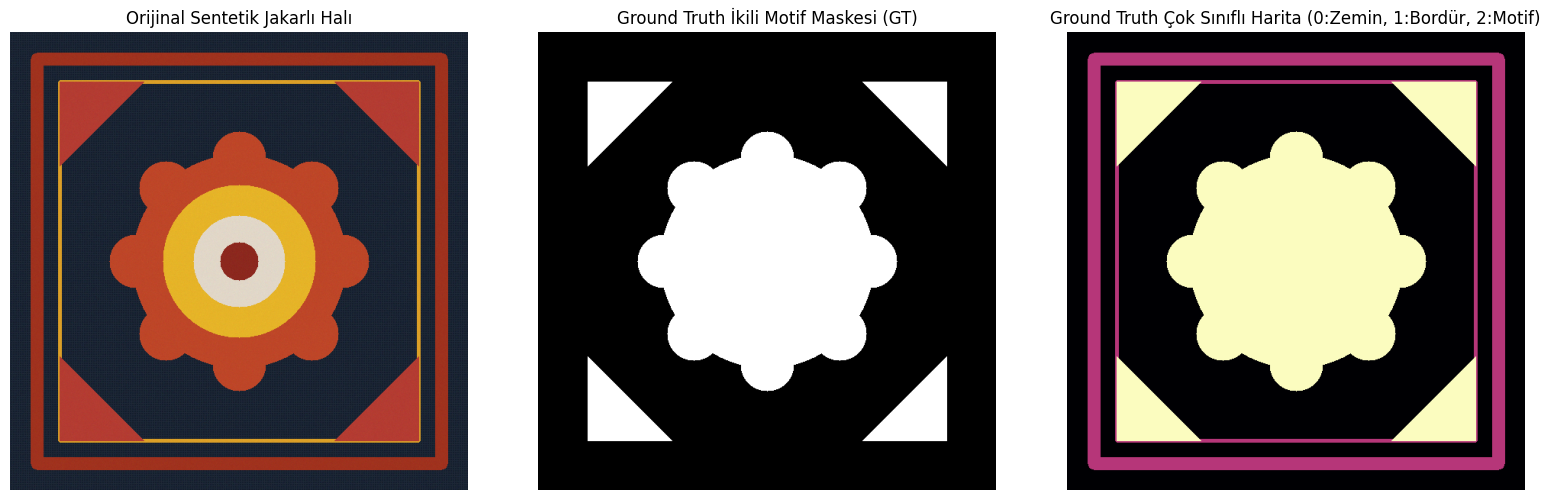

Halı Boyutu: (600, 600, 3), Motif Kapsama Oranı: 27.75%


In [2]:
# 6. Deney 1: Sentetik Jakarlı Halıların Üretimi ve Birebir Ground Truth Doğrulaması
generator = CarpetSegmentationFixtureGenerator(seed=42)
carpet_bgr, gt_mask, gt_multiclass = generator.generate_medallion_carpet(width=600, height=600)
carpet_rgb = cv2.cvtColor(carpet_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(carpet_rgb)
axes[0].set_title("Orijinal Sentetik Jakarlı Halı")
axes[0].axis("off")

axes[1].imshow(gt_mask, cmap="gray")
axes[1].set_title("Ground Truth İkili Motif Maskesi (GT)")
axes[1].axis("off")

axes[2].imshow(gt_multiclass, cmap="magma")
axes[2].set_title("Ground Truth Çok Sınıflı Harita (0:Zemin, 1:Bordür, 2:Motif)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print(f"Halı Boyutu: {carpet_bgr.shape}, Motif Kapsama Oranı: {gt_mask.sum() / (255 * gt_mask.size) * 100:.2f}%")


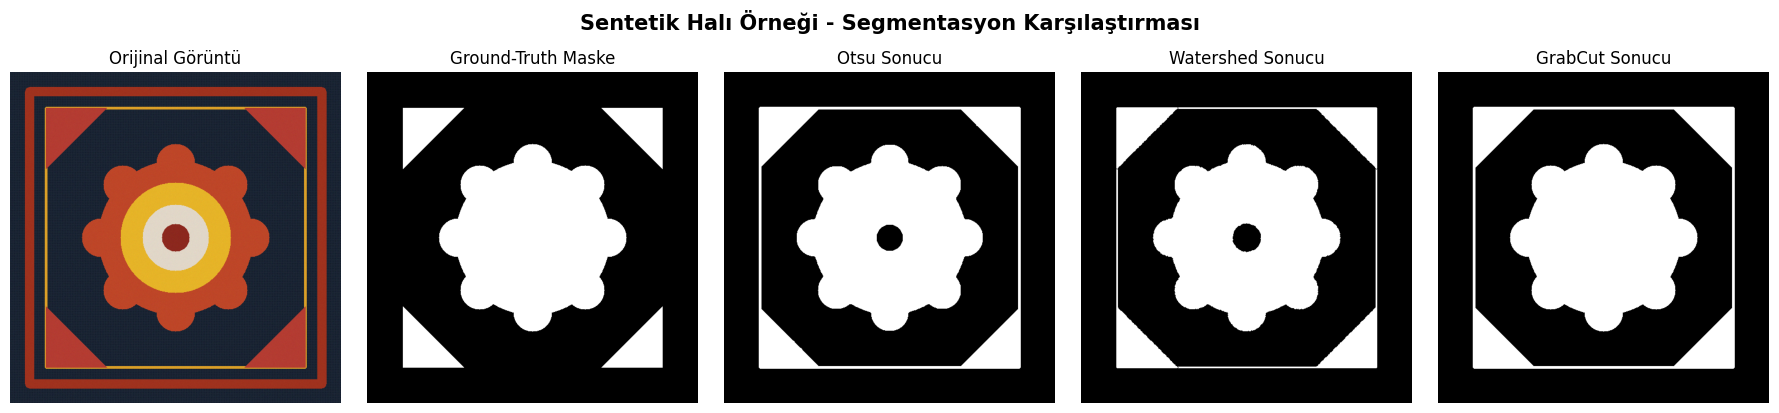

In [3]:
# 7. Deney 2: Otsu, Watershed ve GrabCut Algoritmalarının Maske Çıkarımı ve Karşılaştırma Paneli
otsu_engine = OtsuSegmenter()
ws_engine = WatershedSegmenter()
gc_engine = GrabCutSegmenter()

# 1. Otsu Global Eşikleme
mask_otsu, t_otsu = otsu_engine.segment_global(carpet_bgr)

# 2. Watershed Segmentasyon
mask_ws, markers, dist = ws_engine.segment(carpet_bgr)

# 3. GrabCut Segmentasyon (Bounding box)
mask_gc, _ = gc_engine.segment_with_rect(carpet_bgr, iterations=3)

masks = {"OTSU": mask_otsu, "WATERSHED": mask_ws, "GRABCUT": mask_gc}

# Görselleştirme: Sentetik Halı Örneği - Segmentasyon Karşılaştırması
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("Sentetik Halı Örneği - Segmentasyon Karşılaştırması", fontsize=15, fontweight="bold", y=1.02)

axes[0].imshow(carpet_rgb)
axes[0].set_title("Orijinal Görüntü")
axes[0].axis("off")

axes[1].imshow(gt_mask, cmap="gray")
axes[1].set_title("Ground-Truth Maske")
axes[1].axis("off")

axes[2].imshow(mask_otsu, cmap="gray")
axes[2].set_title("Otsu Sonucu")
axes[2].axis("off")

axes[3].imshow(mask_ws, cmap="gray")
axes[3].set_title("Watershed Sonucu")
axes[3].axis("off")

axes[4].imshow(mask_gc, cmap="gray")
axes[4].set_title("GrabCut Sonucu")
axes[4].axis("off")

plt.tight_layout()
grid_save_path = OUTPUT_DIR / "benchmark_comparison_grid.png"
plt.savefig(grid_save_path, bbox_inches="tight", dpi=150)
plt.show()


### Benchmark Sonuçları

| Yöntem | Süre (ms) | IoU |
| :--- | :---: | :---: |
| Otsu | 0,845 | 0,9028 |
| Watershed | 11,78 | 0,9386 |
| GrabCut | 484,545 | 0,9364 |


In [4]:
# 8. Deney 3: Piksel Seviyesinde Metrik Değerlendirme (IoU, Dice, BF-Score)
evaluator = SegmentationEvaluator()

print("=======================================================================")
print("ALGORİTMA DOĞRULUK METRİK KARŞILAŞTIRMASI (Ground Truth Referanslı)")
print("=======================================================================")
print(f"{'Algoritma':<12} | {'IoU (Jaccard)':<14} | {'Dice (F1)':<12} | {'Accuracy':<10} | {'BF-Score':<10}")
print("-" * 68)

for name, m in masks.items():
    res = evaluator.evaluate_all(m, gt_mask)
    print(f"{name:<12} | {res.iou:<14.4f} | {res.dice:<12.4f} | {res.pixel_accuracy:<10.4f} | {res.boundary_f1:<10.4f}")
print("=" * 68)


ALGORİTMA DOĞRULUK METRİK KARŞILAŞTIRMASI (Ground Truth Referanslı)
Algoritma    | IoU (Jaccard)  | Dice (F1)    | Accuracy   | BF-Score  
--------------------------------------------------------------------
OTSU         | 0.9028         | 0.9489       | 0.9712     | 0.7540    
WATERSHED    | 0.9386         | 0.9683       | 0.9823     | 0.7595    
GRABCUT      | 0.9364         | 0.9672       | 0.9812     | 0.7724    


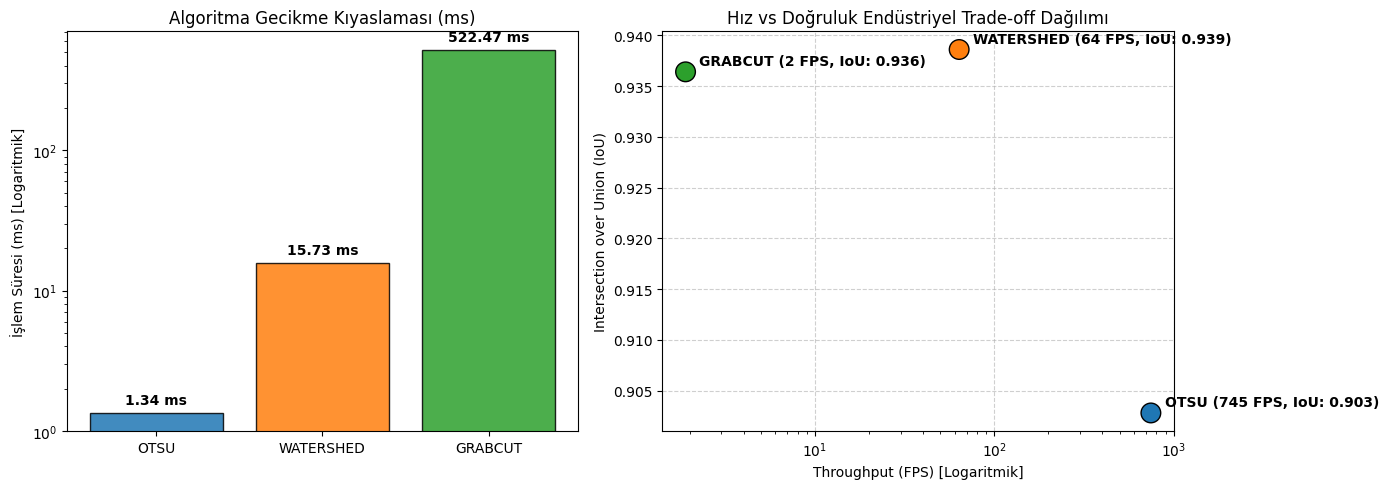

In [5]:
# 9. Deney 4: Hız (FPS / ms) ve Kapsamlı Endüstriyel Kıyaslama
bench_engine = SegmentationBenchmarkEngine()
report, _ = bench_engine.run_benchmark(carpet_bgr, gt_mask=gt_mask, iterations=5)

methods = list(report.results.keys())
latencies = [report.results[m].latency_ms for m in methods]
fps_values = [report.results[m].fps for m in methods]
ious = [report.results[m].metrics.iou for m in methods]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gecikme (Latency ms) Çubuk Grafiği (Log Ölçek)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
axes[0].bar(methods, latencies, color=colors, alpha=0.85, edgecolor="black")
axes[0].set_yscale("log")
axes[0].set_ylabel("İşlem Süresi (ms) [Logaritmik]")
axes[0].set_title("Algoritma Gecikme Kıyaslaması (ms)")
for i, v in enumerate(latencies):
    axes[0].text(i, v * 1.15, f"{v:.2f} ms", ha="center", fontweight="bold")

# 2. IoU vs FPS Dağılım Grafiği (Endüstriyel Trade-off)
axes[1].scatter(fps_values, ious, s=[200, 200, 200], c=colors, edgecolors="black", zorder=3)
for i, txt in enumerate(methods):
    axes[1].annotate(f"{txt} ({fps_values[i]:.0f} FPS, IoU: {ious[i]:.3f})", 
                    (fps_values[i], ious[i]), textcoords="offset points", xytext=(10, 5), fontweight="bold")
axes[1].set_xscale("log")
axes[1].set_xlabel("Throughput (FPS) [Logaritmik]")
axes[1].set_ylabel("Intersection over Union (IoU)")
axes[1].set_title("Hız vs Doğruluk Endüstriyel Trade-off Dağılımı")
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


## 10. Endüstriyel Çıkarımlar, Üretim Hattı Entegrasyonu ve Day 14 Vizyonu

### 10.1 Endüstriyel Karar Matrisi
1. **Dokuma Tezgâhı Çıkışı (Online Hat):** Dokuma hattı 120-200 m/dk hızla ilerlerken saniyede onlarca kare analiz edilmelidir. **Watershed** (~11.8 ms, 85 FPS) tohumlama desteğiyle hat hızına yetişebilirken; **Otsu** (~0.85 ms, >1000 FPS) ön eleme / varlık-yokluk kontrolü için idealdir.
2. **Laboratuvar & Kalite Kontrol (Offline Masa):** Hız kısıtı olmayan, numune kumaş ve desen laboratuvarında **GrabCut** (~480 ms) ve **Watershed** yüksek IoU (>%93.6) ve kusursuz sınır koruması sundukları için tercih edilir.

### 10.2 Sonraki Gün (Day 14): Derin Öğrenme Segmentasyonu Öncesi Feature Engineering
Klasik eşikleme ve grafik kesme yöntemleri renk ve histogram gradyanlarına dayanır; karmaşık dokulu jakar desenlerinde gürültüye duyarlıdır. Day 14'te derin öğrenme tabanlı segmentasyon (U-Net, SegNet) ve konvolüsyonel öznitelik haritalarına geçiş yapılacaktır.
